In [1]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('ai_skepticism_dataset.csv')


In [2]:
print("DataFrame Info:")
df.info()

print("\nDataFrame Shape:")
print(df.shape)

print("\nDescriptive Statistics for Numerical Columns:")
df.describe()

df.columns

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ai_model_name               1000 non-null   object 
 1   query_category              1000 non-null   object 
 2   ai_confidence_percentage    1000 non-null   float64
 3   response_character_count    1000 non-null   int64  
 4   has_cited_sources           1000 non-null   bool   
 5   contains_hedging_words      1000 non-null   bool   
 6   includes_disclaimer         1000 non-null   bool   
 7   answer_detail_level         1000 non-null   object 
 8   respondent_age_bracket      1000 non-null   object 
 9   education_level             1000 non-null   object 
 10  digital_literacy_score      1000 non-null   object 
 11  ai_familiarity_level        1000 non-null   object 
 12  decision_importance         1000 non-null   object 
 13  urgency_level     

Index(['ai_model_name', 'query_category', 'ai_confidence_percentage',
       'response_character_count', 'has_cited_sources',
       'contains_hedging_words', 'includes_disclaimer', 'answer_detail_level',
       'respondent_age_bracket', 'education_level', 'digital_literacy_score',
       'ai_familiarity_level', 'decision_importance', 'urgency_level',
       'belief_alignment_status', 'subject_matter_expertise',
       'trust_score_out_of_10', 'performed_fact_check',
       'fact_check_method_used', 'verification_duration_mins',
       'answer_accuracy_percentage', 'trust_calibration_valid',
       'user_skepticism_category'],
      dtype='object')

In [3]:
df.isnull().sum()

ai_model_name                   0
query_category                  0
ai_confidence_percentage        0
response_character_count        0
has_cited_sources               0
contains_hedging_words          0
includes_disclaimer             0
answer_detail_level             0
respondent_age_bracket          0
education_level                 0
digital_literacy_score          0
ai_familiarity_level            0
decision_importance             0
urgency_level                 221
belief_alignment_status       342
subject_matter_expertise        0
trust_score_out_of_10           0
performed_fact_check            0
fact_check_method_used        372
verification_duration_mins      0
answer_accuracy_percentage      0
trust_calibration_valid         0
user_skepticism_category        0
dtype: int64

In [4]:
df['urgency_level']=df['urgency_level'].fillna(df['urgency_level'].mode()[0])
df['belief_alignment_status']=df['belief_alignment_status'].fillna(df['belief_alignment_status'].mode()[0])
df['fact_check_method_used']=df['fact_check_method_used'].fillna(df['fact_check_method_used'].mode()[0])
df

C:\Users\Hi\AppData\Local\Temp\ipykernel_13560\2121404057.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['belief_alignment_status']=df['belief_alignment_status'].fillna(df['belief_alignment_status'].mode()[0])


,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,education_level,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
0,Claude,math_calculation,93.23,527,True,False,False,Moderate,45-54,Bachelors,...,Low,False,False,10.0,True,Google Search,10.7,80.15,True,Moderate Trust
1,Llama,recipe_cooking,84.47,581,False,False,False,Specific,55-64,PhD,...,Medium,False,True,7.9,True,Asked Expert,44.3,92.33,True,Skeptical
2,Claude,general_knowledge,69.82,484,True,True,False,Very Specific,35-44,High School,...,Medium,True,False,8.6,True,Consulted Documentation,37.5,67.32,True,Moderate Trust
3,Claude,creative_writing,79.61,73,True,True,False,Specific,45-54,Professional,...,Medium,True,False,8.9,True,Checked Official Source,22.7,73.12,True,Moderate Trust
4,Claude,creative_writing,67.71,146,False,True,False,Vague,55-64,Masters,...,Medium,True,True,9.0,True,Academic Paper,43.7,81.05,True,Moderate Trust
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Gemini,math_calculation,94.09,661,True,True,False,Specific,35-44,Masters,...,High,True,True,10.0,False,Asked Colleague,0.0,95.33,True,Blind Trust
996,Llama,financial_advice,62.60,384,True,False,False,Vague,65+,Masters,...,High,True,False,8.4,False,Asked Colleague,0.0,68.18,True,Blind Trust
997,Claude,technical_coding,77.38,166,True,True,False,Specific,35-44,High School,...,Medium,True,True,10.0,True,Cross-referenced Multiple AIs,23.3,92.14,True,Moderate Trust
998,ChatGPT-3.5,math_calculation,98.61,71,False,True,False,Very Specific,25-34,High School,...,Medium,False,False,8.6,True,Asked Expert,43.3,100.00,True,Moderate Trust


In [5]:
print("total duplicated")
df.duplicated().sum()

total duplicated


np.int64(0)

In [6]:
import pandas as pd
from scipy.stats import chi2_contingency

In [7]:
df['ai_model_name'].value_counts()

ai_model_name
Gemini         190
Claude         171
Llama          165
ChatGPT-3.5    160
Mistral        158
GPT-4          156
Name: count, dtype: int64

In [8]:
df['query_category'].value_counts()

query_category
recipe_cooking        101
scientific_facts       96
math_calculation       92
opinion_based          87
medical_advice         84
technical_coding       83
financial_advice       82
general_knowledge      82
legal_advice           81
factual_historical     77
current_events         72
creative_writing       63
Name: count, dtype: int64

In [9]:
df['has_cited_sources'].value_counts()

has_cited_sources
True     525
False    475
Name: count, dtype: int64

In [10]:
df['contains_hedging_words'].value_counts()

contains_hedging_words
True     512
False    488
Name: count, dtype: int64

In [11]:
df['includes_disclaimer'].value_counts()

includes_disclaimer
True     509
False    491
Name: count, dtype: int64

In [12]:
df['answer_detail_level'].value_counts()

answer_detail_level
Moderate         261
Vague            259
Specific         243
Very Specific    237
Name: count, dtype: int64

In [13]:
df['education_level'].value_counts()

education_level
PhD             218
Masters         202
High School     196
Bachelors       195
Professional    189
Name: count, dtype: int64

In [14]:
df['digital_literacy_score'].value_counts()

digital_literacy_score
Low       259
Expert    258
Medium    249
High      234
Name: count, dtype: int64

In [15]:
df['ai_familiarity_level'].value_counts()

ai_familiarity_level
Beginner        218
Expert          201
Advanced        195
First Time      195
Intermediate    191
Name: count, dtype: int64

In [16]:
df['decision_importance'].value_counts()

decision_importance
High        264
Low         261
Medium      248
Critical    227
Name: count, dtype: int64

In [17]:
df['urgency_level'].value_counts()

urgency_level
Medium    487
Low       261
High      252
Name: count, dtype: int64

In [18]:
df['belief_alignment_status'].value_counts()

belief_alignment_status
True     679
False    321
Name: count, dtype: int64

In [19]:
df['subject_matter_expertise'].value_counts()

subject_matter_expertise
False    518
True     482
Name: count, dtype: int64

In [20]:
df['performed_fact_check'].value_counts()

performed_fact_check
True     628
False    372
Name: count, dtype: int64

In [21]:
df['fact_check_method_used'].value_counts()

fact_check_method_used
Asked Colleague                  464
Asked Expert                      84
Google Search                     83
Checked Official Source           79
Personal Testing                  79
Academic Paper                    75
Cross-referenced Multiple AIs     71
Consulted Documentation           65
Name: count, dtype: int64

In [22]:
df['trust_calibration_valid'].value_counts()

trust_calibration_valid
True     727
False    273
Name: count, dtype: int64

In [23]:
df['user_skepticism_category'].value_counts()

user_skepticism_category
Moderate Trust      366
Skeptical           313
Blind Trust         264
Highly Skeptical     57
Name: count, dtype: int64

In [24]:
table=pd.crosstab(df['ai_model_name'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: ai_model_name associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
ai_model_name                                                             
ChatGPT-3.5                        31                 9              62   
Claude                             47                 5              61   
GPT-4                              47                 7              68   
Gemini                             43                18              71   
Llama                              44                10              53   
Mistral                            52                 8              51   

user_skepticism_category  Skeptical  
ai_model_name                        
ChatGPT-3.5                      58  
Claude                           58  
GPT-4                            34  
Gemini                           58  
Llama                            58  
Mistral                          47  
chi2: 26.201412, p-value: 0.0360, Degrees of freedom: 15


In [25]:
if p < alpha:
    print('Reject null: ai_model_name associated with user_skepticism_category.')
else:
    print('No significant association.')  

Reject null: ai_model_name associated with user_skepticism_category.


In [26]:
table=pd.crosstab(df['query_category'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: query_category associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
query_category                                                            
creative_writing                   20                 2              23   
current_events                     20                 4              24   
factual_historical                 35                 0              28   
financial_advice                    6                14              13   
general_knowledge                  21                 0              42   
legal_advice                        9                10              18   
math_calculation                   37                 0              52   
medical_advice                     11                 7              22   
opinion_based                       9                20              16   
recipe_cooking                     40                 0              41   
scientific_facts                   24                 0              49   
technical_coding         

In [27]:
if p < alpha:
    print('Reject null:query_category  associated with user_skepticism_category.')
else:
    print('No significant association.')

Reject null:query_category  associated with user_skepticism_category.


In [28]:
table=pd.crosstab(df['has_cited_sources'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: has_cited_sources associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
has_cited_sources                                                         
False                              92                38             172   
True                              172                19             194   

user_skepticism_category  Skeptical  
has_cited_sources                    
False                           173  
True                            140  
chi2: 32.959795, p-value: 0.0000, Degrees of freedom: 3


In [29]:
if p < alpha:
    print('Reject null:has_cited_sources  associated with user_skepticism_category.')
else:
    print('No significant association.')    

Reject null:has_cited_sources  associated with user_skepticism_category.


In [30]:
table=pd.crosstab(df['contains_hedging_words'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: contains_hedging_words associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
contains_hedging_words                                                    
False                             134                21             207   
True                              130                36             159   

user_skepticism_category  Skeptical  
contains_hedging_words               
False                           126  
True                            187  
chi2: 21.627693, p-value: 0.0001, Degrees of freedom: 3


In [31]:
if p < alpha:
    print('Reject null:contains_hedging_words  associated with user_skepticism_category.')
else:
    print('No significant association.')    

Reject null:contains_hedging_words  associated with user_skepticism_category.


In [32]:
table=pd.crosstab(df['includes_disclaimer'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: includes_disclaimer associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
includes_disclaimer                                                       
False                             135                28             183   
True                              129                29             183   

user_skepticism_category  Skeptical  
includes_disclaimer                  
False                           145  
True                            168  
chi2: 1.520496, p-value: 0.6775, Degrees of freedom: 3


In [33]:
if p < alpha:
    print('Reject null: includes_disclaimer  associated with user_skepticism_category.')
else:
    print('No significant association.')    

No significant association.


In [34]:
df.drop(columns=['includes_disclaimer'],inplace=True)

In [35]:
table=pd.crosstab(df['answer_detail_level'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: answer_detail_level associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
answer_detail_level                                                       
Moderate                           85                13              91   
Specific                           51                12              88   
Vague                              64                18              96   
Very Specific                      64                14              91   

user_skepticism_category  Skeptical  
answer_detail_level                  
Moderate                         72  
Specific                         92  
Vague                            81  
Very Specific                    68  
chi2: 13.435872, p-value: 0.1439, Degrees of freedom: 9


In [36]:
if p < alpha:
    print('Reject null: answer_detail_level associated with user_skepticism_category.')
else:
    print('No significant association.')    

No significant association.


In [37]:
df.drop(columns=['answer_detail_level'],inplace=True)

In [38]:
table=pd.crosstab(df['education_level'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: education level associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
education_level                                                           
Bachelors                          56                10              78   
High School                        72                 9              60   
Masters                            55                14              68   
PhD                                39                17              84   
Professional                       42                 7              76   

user_skepticism_category  Skeptical  
education_level                      
Bachelors                        51  
High School                      55  
Masters                          65  
PhD                              78  
Professional                     64  
chi2: 27.743160, p-value: 0.0060, Degrees of freedom: 12


In [39]:
if p < alpha:
    print('Reject null: education_level  associated with user_skepticism_category.')
else:
    print('No significant association.')    

Reject null: education_level  associated with user_skepticism_category.


In [40]:
table=pd.crosstab(df['digital_literacy_score'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: digital_literacy_level associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
digital_literacy_score                                                    
Expert                             64                16              96   
High                               46                21              84   
Low                                76                 7             106   
Medium                             78                13              80   

user_skepticism_category  Skeptical  
digital_literacy_score               
Expert                           82  
High                             83  
Low                              70  
Medium                           78  
chi2: 21.685674, p-value: 0.0099, Degrees of freedom: 9


In [41]:
if p < alpha:
    print('Reject null: digital_literacy_score associated with user_skepticism_category.')
else:
    print('No significant association.')    

Reject null: digital_literacy_score associated with user_skepticism_category.


In [42]:
table=pd.crosstab(df['ai_familiarity_level'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: ai_familiarity_level associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
ai_familiarity_level                                                      
Advanced                           52                12              63   
Beginner                           72                11              85   
Expert                             44                13              67   
First Time                         53                 6              80   
Intermediate                       43                15              71   

user_skepticism_category  Skeptical  
ai_familiarity_level                 
Advanced                         68  
Beginner                         50  
Expert                           77  
First Time                       56  
Intermediate                     62  


chi2: 22.956139, p-value: 0.0281, Degrees of freedom: 12


In [43]:
if p < alpha:
    print('Reject null: ai_familiarity_level associated with user_skepticism_category.')
else:
    print('No significant association.')    

Reject null: ai_familiarity_level associated with user_skepticism_category.


In [44]:
table=pd.crosstab(df['decision_importance'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: decision_importance associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
decision_importance                                                       
Critical                           26                32              69   
High                               50                10             113   
Low                               105                 8             102   
Medium                             83                 7              82   

user_skepticism_category  Skeptical  
decision_importance                  
Critical                        100  
High                             91  
Low                              46  
Medium                           76  
chi2: 119.649503, p-value: 0.0000, Degrees of freedom: 9


In [45]:
if p < alpha:
    print('Reject null: decision_importance associated with user_skepticism_category.')
else:
    print('No significant association.')    

Reject null: decision_importance associated with user_skepticism_category.


In [46]:
table=pd.crosstab(df['urgency_level'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: urgency_level associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
urgency_level                                                             
High                               86                 8              80   
Low                                58                24             100   
Medium                            120                25             186   

user_skepticism_category  Skeptical  
urgency_level                        
High                             78  
Low                              79  
Medium                          156  
chi2: 19.035569, p-value: 0.0041, Degrees of freedom: 6


In [47]:
if p < alpha:
    print('Reject null: urgency_level associated with user_skepticism_category.')
else:
    print('No significant association.')    

Reject null: urgency_level associated with user_skepticism_category.


In [48]:
table=pd.crosstab(df['belief_alignment_status'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: belief_alignment_status associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
belief_alignment_status                                                   
False                              55                46              87   
True                              209                11             279   

user_skepticism_category  Skeptical  
belief_alignment_status              
False                           133  
True                            180  
chi2: 104.307898, p-value: 0.0000, Degrees of freedom: 3


In [49]:
if p < alpha:
    print('Reject null: belief_alignment_status associated with user_skepticism_category.')
else:
    print('No significant association.')    

Reject null: belief_alignment_status associated with user_skepticism_category.


In [50]:
table=pd.crosstab(df['subject_matter_expertise'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: subject_matter_expertise associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
subject_matter_expertise                                                  
False                             140                27             188   
True                              124                30             178   

user_skepticism_category  Skeptical  
subject_matter_expertise             
False                           163  
True                            150  
chi2: 0.645589, p-value: 0.8859, Degrees of freedom: 3


In [51]:
if p < alpha:
    print('Reject null: subject_matter_expertise associated with user_skepticism_category.')
else:
    print('No significant association.')    

No significant association.


In [52]:
df.drop(columns=['subject_matter_expertise'],inplace=True)

In [53]:
table=pd.crosstab(df['performed_fact_check'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: performed_fact_check associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
performed_fact_check                                                      
False                             264                 0              85   
True                                0                57             281   

user_skepticism_category  Skeptical  
performed_fact_check                 
False                            23  
True                            290  
chi2: 629.436909, p-value: 0.0000, Degrees of freedom: 3


In [54]:
if p < alpha:
    print('Reject null:performed_fact_check  associated with user_skepticism_category.')
else:
    print('No significant association.')    

Reject null:performed_fact_check  associated with user_skepticism_category.


In [55]:
table=pd.crosstab(df['fact_check_method_used'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: fact_check_method_used associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category       Blind Trust  Highly Skeptical  Moderate Trust  \
fact_check_method_used                                                         
Academic Paper                           0                 6              31   
Asked Colleague                        264                 8             127   
Asked Expert                             0                 5              39   
Checked Official Source                  0                 8              35   
Consulted Documentation                  0                 4              31   
Cross-referenced Multiple AIs            0                 7              37   
Google Search                            0                13              32   
Personal Testing                         0                 6              34   

user_skepticism_category       Skeptical  
fact_check_method_used                    
Academic Paper                        38  
Asked Colleague                       65  
Asked Expert               

In [56]:
if p < alpha:
    print('Reject null: fact_check_method_used associated with user_skepticism_category.')
else:
    print('No significant association.')    

Reject null: fact_check_method_used associated with user_skepticism_category.


In [57]:
table=pd.crosstab(df['trust_calibration_valid'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: trust_calibration_valid associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
trust_calibration_valid                                                   
False                              93                10             109   
True                              171                47             257   

user_skepticism_category  Skeptical  
trust_calibration_valid              
False                            61  
True                            252  
chi2: 21.850432, p-value: 0.0001, Degrees of freedom: 3


In [58]:
if p < alpha:
    print('Reject null: trust_calibration_valid associated with user_skepticism_category.')
else:
    print('No significant association.')  

Reject null: trust_calibration_valid associated with user_skepticism_category.


In [59]:
table=pd.crosstab(df['respondent_age_bracket'],df['user_skepticism_category'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'chi2: {chi2:2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')
#if p < alpha:
     #print('reject null: respondent_age_bracket associated with user_skepticism_category.')
#else:
     #print('No significant association)     

user_skepticism_category  Blind Trust  Highly Skeptical  Moderate Trust  \
respondent_age_bracket                                                    
18-24                              40                10              46   
25-34                              42                 9              61   
35-44                              56                 9              68   
45-54                              37                 9              65   
55-64                              37                 9              72   
65+                                52                11              54   

user_skepticism_category  Skeptical  
respondent_age_bracket               
18-24                            55  
25-34                            46  
35-44                            62  
45-54                            48  
55-64                            52  
65+                              50  
chi2: 11.462282, p-value: 0.7192, Degrees of freedom: 15


In [60]:
if p < alpha:
    print('Reject null: respondent_age_bracket associated with user_skepticism_category.')
else:
    print('No significant association.')    

No significant association.


In [61]:
df.drop(columns=['respondent_age_bracket'],inplace=True)

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import _get_covariance, anova_lm

In [63]:
formula = 'ai_confidence_percentage ~ C(user_skepticism_category) '
model = ols(formula, df).fit()
aov_table = anova_lm(model)
print(aov_table)

                                df         sum_sq       mean_sq           F  \
C(user_skepticism_category)    3.0   71427.504221  23809.168074  165.402752   
Residual                     996.0  143370.839375    143.946626         NaN   

                                   PR(>F)  
C(user_skepticism_category)  5.361358e-87  
Residual                              NaN  


In [64]:
df.drop(columns=['ai_confidence_percentage'],inplace=True)

In [65]:
formula = 'answer_accuracy_percentage ~ C(user_skepticism_category) '
model = ols(formula, df).fit()
aov_table = anova_lm(model)
print(aov_table)

                                df        sum_sq       mean_sq           F  \
C(user_skepticism_category)    3.0   80022.71063  26674.236877  106.252177   
Residual                     996.0  250042.31109    251.046497         NaN   

                                   PR(>F)  
C(user_skepticism_category)  1.104662e-59  
Residual                              NaN  


In [66]:
df.drop(columns=['answer_accuracy_percentage'],inplace=True)

In [67]:
formula = 'trust_score_out_of_10 ~ C(user_skepticism_category) '
model = ols(formula, df).fit()
aov_table = anova_lm(model)
print(aov_table)

                                df       sum_sq     mean_sq           F  \
C(user_skepticism_category)    3.0  2217.343753  739.114584  816.727251   
Residual                     996.0   901.351247    0.904971         NaN   

                                    PR(>F)  
C(user_skepticism_category)  7.349217e-268  
Residual                               NaN  


In [68]:
df.drop(columns=['trust_score_out_of_10'],inplace=True)

In [69]:
formula = 'verification_duration_mins ~ C(user_skepticism_category) '
aov_table = anova_lm(model)
print(aov_table)

                                df       sum_sq     mean_sq           F  \
C(user_skepticism_category)    3.0  2217.343753  739.114584  816.727251   
Residual                     996.0   901.351247    0.904971         NaN   

                                    PR(>F)  
C(user_skepticism_category)  7.349217e-268  
Residual                               NaN  


In [70]:
df.drop(columns=['verification_duration_mins'],inplace=True)

In [71]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["ai_model_name"]=le.fit_transform(df["ai_model_name"])
df["query_category"]=le.fit_transform(df["query_category"])
df["has_cited_sources"]=le.fit_transform(df["has_cited_sources"])
df["contains_hedging_words"]=le.fit_transform(df["contains_hedging_words"])
df["education_level"]=le.fit_transform(df["education_level"])
df["digital_literacy_score"]=le.fit_transform(df["digital_literacy_score"])
df["ai_familiarity_level"]=le.fit_transform(df["ai_familiarity_level"])
df["decision_importance"]=le.fit_transform(df["decision_importance"])
df["urgency_level"]=le.fit_transform(df["urgency_level"])
df["belief_alignment_status"]=le.fit_transform(df["belief_alignment_status"])
df["performed_fact_check"]=le.fit_transform(df["performed_fact_check"])
df["fact_check_method_used"]=le.fit_transform(df["fact_check_method_used"])
df["trust_calibration_valid"]=le.fit_transform(df["trust_calibration_valid"])
df["user_skepticism_category"]=le.fit_transform(df["user_skepticism_category"])



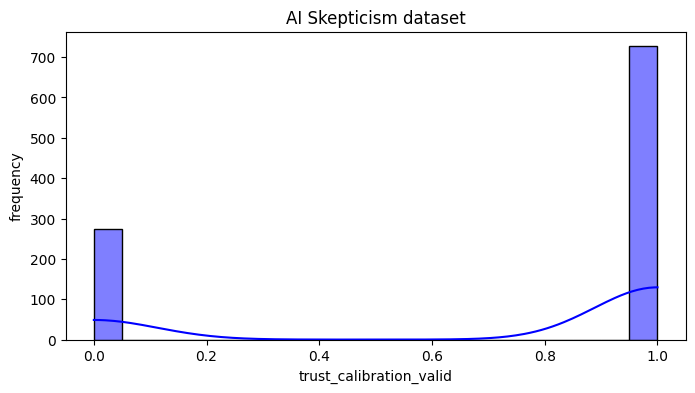

In [72]:
plt.figure(figsize=(8,4))
sns.histplot(df['trust_calibration_valid'],bins=20,kde=True,color='blue')
plt.title('AI Skepticism dataset')
plt.xlabel('trust_calibration_valid')
plt.ylabel('frequency')
plt.show()

C:\Users\Hi\AppData\Local\Temp\ipykernel_13560\2011329046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='education_level', data=df, palette='viridis')


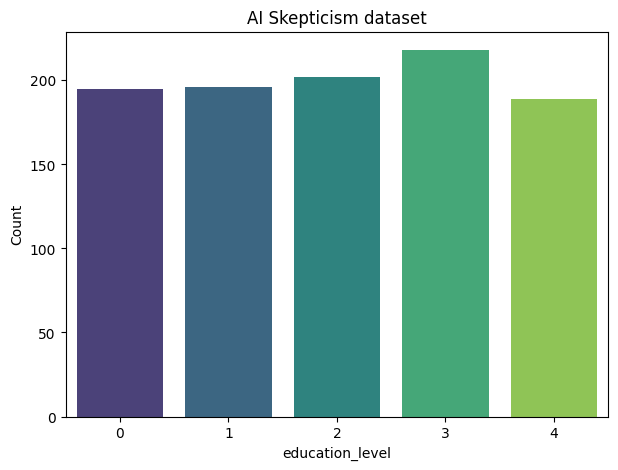

In [73]:
plt.figure(figsize=(7, 5))
sns.countplot(x='education_level', data=df, palette='viridis')
plt.title('AI Skepticism dataset')
plt.xlabel('education_level')
plt.ylabel('Count')
plt.show()

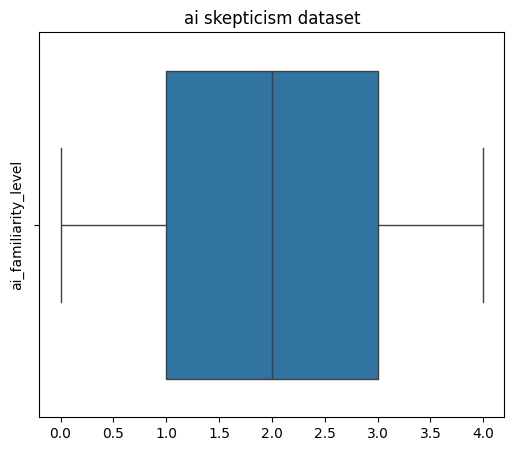

In [74]:
plt.figure(figsize=(6,5))
sns.boxplot(x='ai_familiarity_level',data=df)
plt.title('ai skepticism dataset')
plt.xlabel('')
plt.ylabel('ai_familiarity_level')
plt.show()

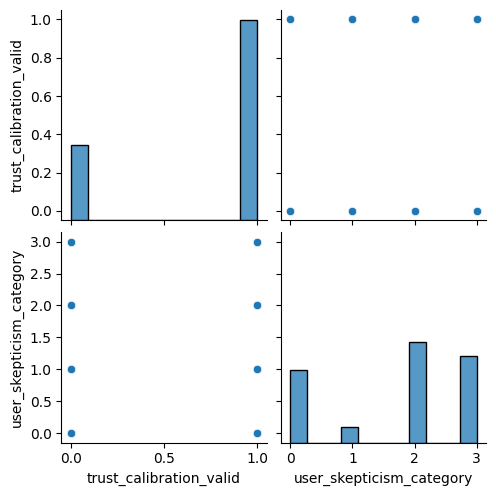

In [75]:
sns.pairplot(df[['trust_calibration_valid','user_skepticism_category']])

In [76]:
x=df.drop(["user_skepticism_category"],axis=1)

y=df["user_skepticism_category"]
x

,ai_model_name,query_category,response_character_count,has_cited_sources,contains_hedging_words,education_level,digital_literacy_score,ai_familiarity_level,decision_importance,urgency_level,belief_alignment_status,performed_fact_check,fact_check_method_used,trust_calibration_valid
0,1,6,527,1,0,0,2,4,2,1,0,1,6,1
1,4,9,581,0,0,3,0,3,1,2,0,1,2,1
2,1,4,484,1,1,1,3,4,0,2,1,1,4,1
3,1,0,73,1,1,4,2,0,1,2,1,1,3,1
4,1,0,146,0,1,2,2,2,2,2,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,6,661,1,1,2,3,1,2,0,1,0,1,1
996,4,3,384,1,0,2,0,0,1,0,1,0,1,1
997,1,11,166,1,1,1,3,0,1,2,1,1,5,1
998,0,6,71,0,1,1,2,2,1,2,0,1,2,1


In [77]:
y

0      2
1      3
2      2
3      2
4      2
      ..
995    0
996    0
997    2
998    2
999    3
Name: user_skepticism_category, Length: 1000, dtype: int64

In [78]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(x)
x

array([[-0.89344218,  0.05249737,  0.44227054, ...,  0.76964712,
         1.58838455,  0.61279345],
       [ 0.88987555,  0.94228324,  0.68602535, ...,  0.76964712,
        -0.24524841,  0.61279345],
       [-0.89344218, -0.54069322,  0.24816948, ...,  0.76964712,
         0.67156807,  0.61279345],
       ...,
       [-0.89344218,  1.53547382, -1.18727553, ...,  0.76964712,
         1.12997631,  0.61279345],
       [-1.48788143,  0.05249737, -1.61610344, ...,  0.76964712,
        -0.24524841,  0.61279345],
       [ 0.88987555,  0.64568795, -1.38137659, ...,  0.76964712,
         2.04679279,  0.61279345]], shape=(1000, 14))

In [79]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
y_pred

(800, 14)
(200, 14)
(800,)
(200,)


array([0, 3, 2, 3, 0, 3, 3, 0, 0, 3, 2, 2, 0, 2, 2, 3, 1, 0, 3, 3, 0, 0,
       0, 0, 0, 3, 2, 0, 1, 0, 0, 2, 2, 2, 3, 2, 3, 3, 3, 3, 0, 3, 1, 2,
       1, 3, 3, 2, 2, 3, 2, 1, 2, 0, 3, 0, 3, 2, 0, 3, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 0, 2, 0, 0, 3, 2, 0, 2, 3, 0, 2, 0, 3, 2, 3, 2, 3, 3, 2,
       0, 0, 1, 0, 0, 3, 0, 0, 0, 2, 2, 3, 3, 0, 0, 2, 2, 2, 3, 3, 0, 1,
       0, 2, 3, 2, 3, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 3, 2, 2, 3, 2,
       2, 0, 2, 0, 2, 2, 3, 3, 0, 3, 3, 2, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2,
       0, 2, 3, 0, 3, 3, 3, 0, 0, 0, 0, 2, 3, 3, 2, 3, 2, 1, 0, 3, 0, 2,
       2, 0, 3, 3, 0, 3, 3, 3, 3, 0, 0, 1, 3, 0, 3, 3, 0, 3, 2, 2, 0, 3,
       3, 2])

In [80]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


0.63
[[53  0  4  0]
 [ 0  3  1 11]
 [ 9  1 38 17]
 [ 4  5 22 32]]
              precision    recall  f1-score   support

           0       0.80      0.93      0.86        57
           1       0.33      0.20      0.25        15
           2       0.58      0.58      0.58        65
           3       0.53      0.51      0.52        63

    accuracy                           0.63       200
   macro avg       0.56      0.56      0.55       200
weighted avg       0.61      0.63      0.62       200



In [81]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_test,y_test)
y_pred=lr.predict(x_test)
y_pred

array([0, 3, 0, 3, 0, 3, 1, 0, 0, 2, 2, 3, 0, 2, 2, 2, 1, 0, 2, 3, 0, 0,
       0, 0, 0, 2, 2, 0, 3, 0, 0, 3, 2, 2, 2, 3, 3, 3, 3, 3, 0, 3, 3, 3,
       3, 3, 3, 2, 2, 2, 2, 3, 0, 0, 1, 0, 3, 2, 0, 1, 0, 2, 0, 3, 3, 2,
       2, 0, 0, 0, 2, 0, 0, 3, 2, 0, 2, 2, 0, 2, 0, 3, 2, 2, 2, 2, 3, 2,
       0, 0, 3, 0, 0, 2, 0, 0, 0, 0, 2, 3, 3, 0, 0, 3, 2, 2, 3, 2, 0, 3,
       0, 2, 3, 3, 3, 3, 0, 2, 0, 2, 2, 0, 0, 2, 2, 0, 0, 2, 2, 3, 2, 2,
       2, 0, 2, 0, 2, 2, 3, 2, 0, 3, 3, 3, 3, 2, 0, 0, 3, 2, 2, 0, 2, 2,
       0, 2, 3, 0, 2, 3, 3, 0, 0, 0, 0, 3, 3, 1, 2, 2, 3, 1, 0, 3, 0, 2,
       2, 0, 3, 3, 0, 3, 1, 3, 3, 0, 0, 3, 3, 0, 3, 3, 0, 2, 3, 2, 0, 3,
       3, 2])

In [82]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.71
[[56  0  0  1]
 [ 0  5  4  6]
 [10  0 41 14]
 [ 3  2 18 40]]
              precision    recall  f1-score   support

           0       0.81      0.98      0.89        57
           1       0.71      0.33      0.45        15
           2       0.65      0.63      0.64        65
           3       0.66      0.63      0.65        63

    accuracy                           0.71       200
   macro avg       0.71      0.65      0.66       200
weighted avg       0.70      0.71      0.70       200



In [83]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)
y_pred

array([2, 2, 0, 3, 0, 2, 1, 0, 2, 3, 0, 2, 2, 3, 2, 2, 3, 0, 3, 1, 0, 0,
       0, 0, 2, 2, 2, 0, 3, 2, 0, 2, 2, 3, 2, 2, 2, 1, 2, 3, 0, 1, 3, 3,
       1, 2, 3, 3, 3, 2, 3, 1, 0, 0, 3, 0, 2, 2, 0, 1, 0, 3, 2, 2, 3, 3,
       2, 0, 0, 2, 3, 0, 0, 1, 2, 0, 2, 3, 2, 3, 0, 2, 2, 2, 2, 2, 1, 2,
       0, 2, 3, 0, 0, 1, 2, 0, 0, 0, 2, 2, 3, 0, 0, 2, 2, 3, 2, 3, 0, 1,
       0, 3, 3, 3, 2, 0, 0, 2, 2, 3, 2, 3, 2, 2, 0, 0, 2, 3, 2, 2, 2, 2,
       2, 0, 3, 0, 3, 3, 2, 3, 2, 3, 2, 3, 2, 3, 0, 0, 2, 2, 2, 0, 1, 2,
       0, 2, 2, 0, 3, 2, 2, 0, 0, 2, 0, 2, 1, 3, 2, 2, 2, 1, 0, 2, 0, 3,
       2, 0, 2, 3, 0, 2, 3, 2, 3, 0, 2, 3, 1, 0, 3, 1, 0, 2, 3, 3, 2, 3,
       3, 2])

In [84]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.61
[[46  0 11  0]
 [ 0  8  1  6]
 [ 7  2 40 16]
 [ 1  6 28 28]]
              precision    recall  f1-score   support

           0       0.85      0.81      0.83        57
           1       0.50      0.53      0.52        15
           2       0.50      0.62      0.55        65
           3       0.56      0.44      0.50        63

    accuracy                           0.61       200
   macro avg       0.60      0.60      0.60       200
weighted avg       0.62      0.61      0.61       200



In [85]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_test,y_test)
y_pred=dt.predict(x_test)
y_pred

array([0, 1, 0, 3, 0, 2, 1, 0, 0, 3, 2, 3, 0, 3, 2, 2, 3, 2, 3, 1, 0, 0,
       0, 2, 3, 2, 3, 0, 1, 2, 0, 2, 2, 3, 2, 3, 2, 3, 3, 3, 0, 1, 3, 2,
       1, 2, 2, 2, 2, 2, 3, 3, 2, 0, 1, 0, 3, 2, 2, 1, 0, 2, 0, 2, 3, 3,
       2, 0, 0, 0, 3, 0, 2, 3, 2, 0, 2, 2, 2, 3, 0, 3, 2, 3, 2, 2, 2, 2,
       0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 2, 3, 3, 0, 0, 3, 2, 3, 3, 2, 0, 2,
       0, 2, 1, 2, 3, 0, 0, 2, 2, 3, 2, 3, 0, 2, 3, 0, 2, 1, 2, 3, 2, 2,
       2, 0, 2, 0, 2, 2, 3, 1, 0, 3, 2, 2, 3, 2, 0, 2, 3, 2, 2, 0, 1, 2,
       0, 2, 3, 0, 3, 2, 3, 0, 0, 0, 0, 3, 3, 1, 3, 3, 3, 1, 0, 3, 0, 3,
       3, 0, 3, 2, 0, 3, 3, 3, 3, 0, 3, 3, 3, 0, 3, 3, 0, 2, 3, 2, 0, 3,
       3, 2])

In [86]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
[[57  0  0  0]
 [ 0 15  0  0]
 [ 0  0 65  0]
 [ 0  0  0 63]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        57
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        65
           3       1.00      1.00      1.00        63

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [87]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
y_pred

array([0, 3, 0, 3, 0, 3, 3, 0, 0, 3, 0, 2, 0, 2, 3, 2, 3, 0, 3, 3, 0, 0,
       0, 0, 0, 2, 2, 0, 3, 0, 0, 2, 2, 2, 2, 3, 2, 3, 2, 3, 0, 1, 3, 2,
       1, 3, 2, 2, 2, 2, 3, 1, 2, 0, 3, 0, 2, 2, 0, 3, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 0, 3, 0, 0, 2, 2, 0, 2, 3, 0, 3, 0, 2, 2, 2, 2, 3, 3, 2,
       0, 0, 3, 0, 0, 3, 0, 0, 0, 0, 2, 2, 3, 0, 0, 2, 2, 2, 3, 3, 0, 3,
       0, 2, 3, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 2, 2, 0, 0, 3, 2, 2, 3, 2,
       3, 0, 2, 0, 2, 2, 3, 3, 0, 3, 3, 2, 2, 2, 0, 0, 3, 2, 2, 0, 3, 2,
       0, 2, 2, 0, 3, 2, 3, 0, 0, 0, 0, 2, 3, 3, 3, 2, 2, 3, 0, 3, 0, 3,
       2, 0, 3, 3, 0, 3, 3, 3, 3, 0, 2, 3, 3, 0, 3, 3, 0, 2, 3, 2, 0, 2,
       3, 2])

In [88]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.675
[[56  0  1  0]
 [ 0  2  0 13]
 [10  0 43 12]
 [ 1  1 27 34]]
              precision    recall  f1-score   support

           0       0.84      0.98      0.90        57
           1       0.67      0.13      0.22        15
           2       0.61      0.66      0.63        65
           3       0.58      0.54      0.56        63

    accuracy                           0.68       200
   macro avg       0.67      0.58      0.58       200
weighted avg       0.67      0.68      0.66       200



In [89]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_test,y_test)
y_pred=rf.predict(x_test)
y_pred

array([0, 1, 0, 3, 0, 2, 1, 0, 0, 3, 2, 3, 0, 3, 2, 2, 3, 2, 3, 1, 0, 0,
       0, 2, 3, 2, 3, 0, 1, 2, 0, 2, 2, 3, 2, 3, 2, 3, 3, 3, 0, 1, 3, 2,
       1, 2, 2, 2, 2, 2, 3, 3, 2, 0, 1, 0, 3, 2, 2, 1, 0, 2, 0, 2, 3, 3,
       2, 0, 0, 0, 3, 0, 2, 3, 2, 0, 2, 2, 2, 3, 0, 3, 2, 3, 2, 2, 2, 2,
       0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 2, 3, 3, 0, 0, 3, 2, 3, 3, 2, 0, 2,
       0, 2, 1, 2, 3, 0, 0, 2, 2, 3, 2, 3, 0, 2, 3, 0, 2, 1, 2, 3, 2, 2,
       2, 0, 2, 0, 2, 2, 3, 1, 0, 3, 2, 2, 3, 2, 0, 2, 3, 2, 2, 0, 1, 2,
       0, 2, 3, 0, 3, 2, 3, 0, 0, 0, 0, 3, 3, 1, 3, 3, 3, 1, 0, 3, 0, 3,
       3, 0, 3, 2, 0, 3, 3, 3, 3, 0, 3, 3, 3, 0, 3, 3, 0, 2, 3, 2, 0, 3,
       3, 2])

In [90]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
[[57  0  0  0]
 [ 0 15  0  0]
 [ 0  0 65  0]
 [ 0  0  0 63]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        57
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        65
           3       1.00      1.00      1.00        63

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [91]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier()
kn.fit(x_train,y_train)
y_pred=kn.predict(x_test)
y_pred

array([0, 3, 0, 2, 0, 3, 1, 0, 0, 2, 0, 2, 0, 2, 3, 2, 3, 0, 3, 3, 0, 0,
       0, 3, 0, 2, 3, 0, 3, 0, 0, 2, 2, 3, 2, 2, 2, 3, 2, 3, 0, 1, 1, 2,
       3, 3, 2, 3, 3, 3, 2, 3, 3, 0, 3, 0, 2, 2, 0, 1, 0, 3, 0, 2, 0, 2,
       2, 0, 0, 0, 3, 0, 0, 1, 2, 2, 2, 3, 0, 3, 0, 3, 2, 3, 2, 3, 3, 2,
       0, 0, 3, 0, 0, 3, 0, 0, 0, 0, 2, 3, 3, 0, 0, 2, 2, 2, 3, 3, 0, 3,
       0, 2, 3, 3, 3, 2, 0, 0, 0, 3, 2, 0, 0, 3, 0, 2, 0, 3, 0, 2, 3, 2,
       3, 0, 2, 0, 2, 2, 1, 3, 0, 1, 3, 2, 3, 3, 2, 0, 2, 2, 2, 0, 2, 2,
       0, 2, 1, 0, 3, 2, 2, 0, 0, 0, 0, 2, 2, 2, 3, 2, 2, 3, 0, 1, 0, 3,
       2, 2, 3, 3, 0, 3, 1, 3, 3, 2, 2, 1, 2, 2, 1, 2, 0, 2, 2, 3, 0, 3,
       3, 2])

In [92]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.56
[[50  0  7  0]
 [ 0  3  2 10]
 [11  0 32 22]
 [ 4  9 23 27]]
              precision    recall  f1-score   support

           0       0.77      0.88      0.82        57
           1       0.25      0.20      0.22        15
           2       0.50      0.49      0.50        65
           3       0.46      0.43      0.44        63

    accuracy                           0.56       200
   macro avg       0.49      0.50      0.50       200
weighted avg       0.54      0.56      0.55       200



In [93]:
from sklearn.neighbors import KNeighborsClassifier
kn=KNeighborsClassifier()
kn.fit(x_test,y_test)
y_pred=kn.predict(x_test)
y_pred

array([0, 2, 0, 3, 0, 2, 3, 0, 0, 2, 0, 0, 0, 2, 2, 2, 1, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 0, 3, 0, 0, 2, 2, 3, 2, 3, 3, 2, 3, 2, 0, 1, 1, 3,
       1, 3, 2, 2, 2, 2, 3, 1, 0, 0, 3, 0, 3, 3, 2, 3, 0, 2, 0, 2, 2, 2,
       0, 0, 0, 0, 3, 0, 2, 3, 2, 0, 2, 3, 0, 3, 0, 3, 2, 2, 2, 0, 3, 2,
       0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 2, 3, 3, 0, 0, 3, 2, 2, 2, 2, 0, 2,
       0, 2, 2, 2, 3, 0, 0, 0, 0, 2, 2, 3, 0, 2, 0, 0, 0, 2, 2, 3, 2, 0,
       2, 0, 2, 0, 2, 2, 3, 2, 0, 1, 2, 0, 2, 2, 0, 0, 3, 2, 2, 0, 1, 2,
       0, 2, 3, 0, 2, 2, 2, 0, 0, 0, 0, 3, 3, 3, 2, 2, 3, 3, 0, 1, 0, 3,
       0, 0, 2, 2, 0, 2, 1, 3, 2, 0, 0, 2, 3, 0, 3, 3, 0, 1, 3, 2, 0, 2,
       3, 2])

In [94]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.68
[[57  0  0  0]
 [ 1  4  4  6]
 [13  1 45  6]
 [ 5  6 22 30]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86        57
           1       0.36      0.27      0.31        15
           2       0.63      0.69      0.66        65
           3       0.71      0.48      0.57        63

    accuracy                           0.68       200
   macro avg       0.62      0.61      0.60       200
weighted avg       0.67      0.68      0.66       200



In [95]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)
y_pred

array([0, 3, 2, 3, 0, 3, 3, 0, 0, 3, 0, 2, 0, 2, 3, 2, 3, 0, 3, 3, 0, 0,
       0, 0, 0, 2, 2, 0, 3, 0, 0, 2, 2, 2, 2, 2, 2, 3, 2, 3, 0, 3, 3, 2,
       3, 3, 2, 2, 2, 3, 2, 3, 2, 0, 3, 0, 2, 2, 0, 3, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 0, 3, 0, 0, 3, 2, 0, 2, 3, 0, 2, 0, 3, 2, 3, 2, 3, 3, 2,
       0, 0, 3, 0, 0, 3, 0, 0, 0, 2, 2, 3, 3, 0, 0, 2, 2, 2, 3, 3, 0, 3,
       0, 2, 3, 2, 3, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0, 0, 0, 3, 2, 2, 3, 2,
       3, 0, 2, 0, 2, 2, 3, 3, 0, 3, 3, 2, 2, 2, 0, 0, 2, 2, 2, 0, 3, 2,
       0, 2, 3, 0, 3, 2, 3, 0, 0, 0, 0, 2, 2, 2, 3, 2, 2, 3, 0, 3, 0, 2,
       2, 0, 3, 3, 0, 3, 3, 3, 3, 0, 0, 2, 3, 0, 3, 3, 0, 3, 2, 2, 0, 3,
       3, 2])

In [96]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.64
[[53  0  4  0]
 [ 0  0  1 14]
 [10  0 41 14]
 [ 3  0 26 34]]
              precision    recall  f1-score   support

           0       0.80      0.93      0.86        57
           1       0.00      0.00      0.00        15
           2       0.57      0.63      0.60        65
           3       0.55      0.54      0.54        63

    accuracy                           0.64       200
   macro avg       0.48      0.53      0.50       200
weighted avg       0.59      0.64      0.61       200



C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [97]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_test,y_test)
y_pred=svm.predict(x_test)
y_pred

array([0, 3, 0, 3, 0, 2, 3, 0, 0, 2, 2, 0, 0, 2, 2, 2, 3, 0, 3, 3, 0, 0,
       0, 2, 0, 2, 2, 0, 3, 2, 0, 2, 2, 2, 2, 3, 2, 3, 3, 3, 0, 3, 3, 3,
       3, 2, 3, 2, 2, 2, 3, 3, 0, 0, 3, 0, 3, 2, 0, 3, 0, 2, 0, 2, 3, 3,
       2, 0, 0, 0, 2, 0, 2, 3, 2, 0, 2, 3, 0, 3, 0, 3, 2, 3, 2, 2, 3, 2,
       0, 0, 3, 0, 0, 2, 0, 0, 0, 0, 2, 3, 3, 0, 0, 3, 2, 3, 3, 2, 0, 3,
       0, 2, 3, 2, 3, 0, 0, 0, 0, 2, 2, 0, 0, 2, 3, 0, 0, 2, 2, 3, 2, 2,
       2, 0, 2, 0, 2, 2, 3, 2, 0, 3, 3, 2, 3, 2, 0, 0, 3, 2, 2, 0, 2, 2,
       0, 2, 3, 0, 2, 2, 3, 0, 0, 0, 0, 3, 3, 3, 2, 3, 3, 3, 0, 3, 0, 2,
       2, 0, 3, 3, 0, 3, 3, 3, 3, 0, 0, 3, 3, 0, 3, 3, 0, 2, 3, 2, 0, 3,
       3, 2])

In [98]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.78
[[57  0  0  0]
 [ 0  0  4 11]
 [ 8  0 50  7]
 [ 4  0 10 49]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.90        57
           1       0.00      0.00      0.00        15
           2       0.78      0.77      0.78        65
           3       0.73      0.78      0.75        63

    accuracy                           0.78       200
   macro avg       0.58      0.64      0.61       200
weighted avg       0.72      0.78      0.75       200



C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [99]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)
y_pred

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1])

In [100]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.36
[[57  0  0  0]
 [ 0 15  0  0]
 [13 52  0  0]
 [ 6 57  0  0]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86        57
           1       0.12      1.00      0.22        15
           2       0.00      0.00      0.00        65
           3       0.00      0.00      0.00        63

    accuracy                           0.36       200
   macro avg       0.22      0.50      0.27       200
weighted avg       0.22      0.36      0.26       200



C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [101]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_test,y_test)
y_pred=nb.predict(x_test)
y_pred

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1])

In [102]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.36
[[57  0  0  0]
 [ 0 15  0  0]
 [13 52  0  0]
 [ 6 57  0  0]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86        57
           1       0.12      1.00      0.22        15
           2       0.00      0.00      0.00        65
           3       0.00      0.00      0.00        63

    accuracy                           0.36       200
   macro avg       0.22      0.50      0.27       200
weighted avg       0.22      0.36      0.26       200



C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is